# Env Setup

In [33]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import pylab as py
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input
import random

# Load Data

In [2]:
df = pd.read_csv('Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 493.2 KB


# Clean up

In [4]:
# clean-up code here if any
df = pd.get_dummies(df, dtype = int, drop_first = True)
df.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
0,7,99,9,1,91.0,1
1,4,82,4,2,65.0,0
2,8,51,7,2,45.0,1
3,5,52,5,2,36.0,1
4,7,75,8,5,66.0,0


# Exploration

In [5]:
# Exploration code here

# Method 1: MLR

### check for multicoliniarity:

In [6]:
cor = df.drop('Performance Index', axis=1).corr()
print(cor)

                                  Hours Studied  Previous Scores  Sleep Hours  \
Hours Studied                          1.000000        -0.012390     0.001245   
Previous Scores                       -0.012390         1.000000     0.005944   
Sleep Hours                            0.001245         0.005944     1.000000   
Sample Question Papers Practiced       0.017463         0.007888     0.003990   
Extracurricular Activities_Yes         0.003873         0.008369    -0.023284   

                                  Sample Question Papers Practiced  \
Hours Studied                                             0.017463   
Previous Scores                                           0.007888   
Sleep Hours                                               0.003990   
Sample Question Papers Practiced                          1.000000   
Extracurricular Activities_Yes                            0.013103   

                                  Extracurricular Activities_Yes  
Hours Studied            

In [7]:
pd.Series(np.linalg.inv(cor.values).diagonal(), index = cor.index)

Hours Studied                       1.000478
Previous Scores                     1.000326
Sleep Hours                         1.000600
Sample Question Papers Practiced    1.000557
Extracurricular Activities_Yes      1.000802
dtype: float64

There are no predictor variables with VIF values greater than 5 so no verriable is concerned to have high correlation.

### Build MLR model:

In [8]:
model = smf.ols(
    formula='Q("Performance Index") ~ Q("Hours Studied") + Q("Previous Scores") + Q("Sleep Hours") + Q("Extracurricular Activities_Yes") + Q("Sample Question Papers Practiced")',
    data=df
)
result = model.fit()

In [9]:
predictions = result.predict()
residuals = result.resid
exog = result.model.exog

print (len(df))
print (len(predictions))
print(len(residuals))
print(len(exog))

10000
10000
10000
10000


### Check for heteroscedasticity:

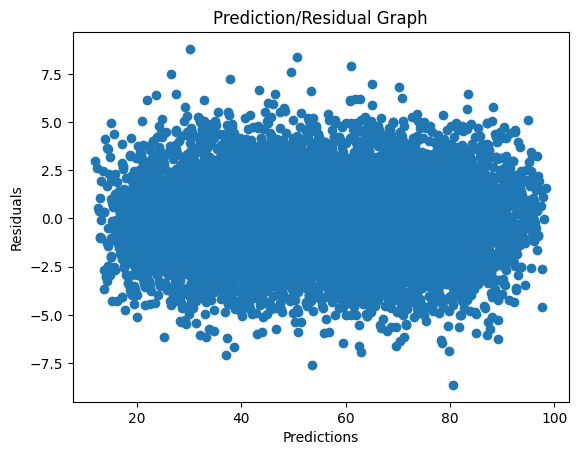

In [10]:
plt.scatter(predictions, residuals)
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.title('Prediction/Residual Graph')
plt.show()

In [11]:
lagrange, l_p_value, f_value, f_p_value = het_breuschpagan(residuals, exog)
print (l_p_value)
print (f_p_value)

0.8266745765790919
0.8267804553854452


We fail to reject the null hypothesis of homoscedasticity therefore we infer that heteroscedasticity does not exist.

The visual and statistical results show that the assumption is met.

### Check for normality of residuals

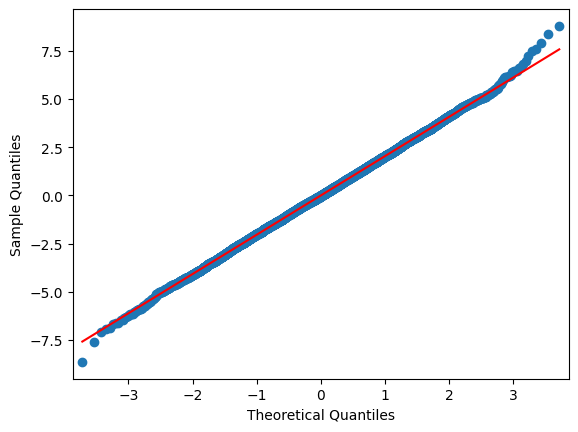

Statistic=1.000, p=0.386
Sample looks Gaussian (fail to reject H0)


C:\Users\Nati\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


In [12]:
sm.qqplot(residuals, line='s')
plt.show()
stat, p = shapiro(residuals)
print('Statistic=%.3f, p=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Sample looks Gaussian (fail to reject H0)')
else:
    print('Sample does not look Gaussian (reject H0)')

The visual test suggests the residual are normally distributed, and furthermore the shapiro-wilk test shwes that we fail to reject the null hypothesis of normality. However it is important to mention that shapiro-wilk test does not perofrm well for data sets with size greater than 5000 (our dataset size is 10,000) but given the visual test it is safe to say the assumption is met.

In [13]:
dw_test = durbin_watson(residuals)
print(dw_test)

2.0009001250688563


**** Need to add notes on durbin_watson test (correlation between residuals) *****

In [14]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     Q("Performance Index")   R-squared:                       0.989
Model:                                OLS   Adj. R-squared:                  0.989
Method:                     Least Squares   F-statistic:                 1.757e+05
Date:                    Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                            22:52:15   Log-Likelihood:                -21307.
No. Observations:                   10000   AIC:                         4.263e+04
Df Residuals:                        9994   BIC:                         4.267e+04
Df Model:                               5                                         
Covariance Type:                nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                               -34.0756      0.127   -268.010      0.000     -34.325     -33.826
Q("Hours Studied")                        2.8530      0.008    362.353      0.000       2.838       2.868
Q("Previous Scores")                      1.0184      0.001    866.450      0.000       1.016       1.021
Q("Sleep Hours")                          0.4806      0.012     39.972      0.000       0.457       0.504
Q("Extracurricular Activities_Yes")       0.6129      0.041     15.029      0.000       0.533       0.693
Q("Sample Question Papers Practiced")     0.1938      0.007     27.257      0.000       0.180       0.208
==============================================================================
Omnibus:                        3.851   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.146   Jarque-Bera (JB):                4.036
Skew:                           0.013   Prob(JB):                        0.133
Kurtosis:                       3.095   Cond. No.                         452.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

$\hat{Y} = - 34.08 + 2.85X_{HS} + 1.02X_{PS} + 0.48X_{SH} + 0.61X_{EAYes} + 0.19X_{SQPP}$

# Method 2 - Random Forest regression:

Define x and y 

In [15]:
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 5)
y shape: (10000,)


Split to traning set and testing set using a 80/20 split. A seed (random_state) is used to replicate the split.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 5)
X_test shape: (2000, 5)
y_train shape: (8000,)
y_test shape: (2000,)


Fit the random forest model.

In [18]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Run predictions on training and test set

In [19]:
rf_train_predictions = rf_model.predict(X_train)
rf_test_predictions = rf_model.predict(X_test)

rf_train_residuals = y_train - rf_train_predictions
rf_test_residuals = y_test - rf_test_predictions

Method to show evaluation metrics

In [20]:
def eval_metrics(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print("RMSE:", round(rmse, 3))
    print("MAE:", round(mae, 3))
    print("R-squared:", round(r2, 3))

In [21]:
eval_metrics(y_train, rf_train_predictions, "Random Forest Training Results")
print()
eval_metrics(y_test, rf_test_predictions, "Random Forest Testing Results")

Random Forest Training Results
RMSE: 0.962
MAE: 0.743
R-squared: 0.997

Random Forest Testing Results
RMSE: 2.266
MAE: 1.811
R-squared: 0.986


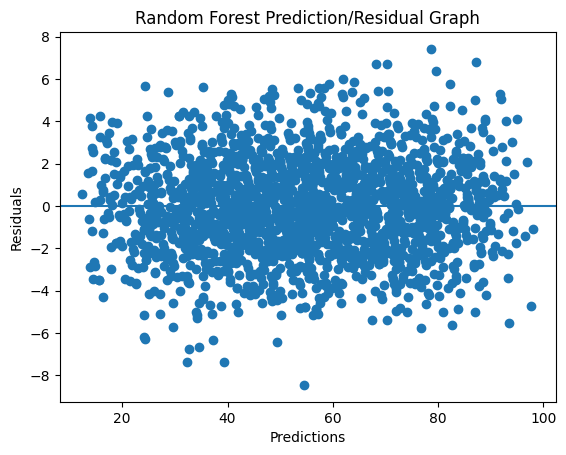

In [22]:
plt.scatter(rf_test_predictions, rf_test_residuals)
plt.axhline(y=0)
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.title('Random Forest Prediction/Residual Graph')
plt.show()

In [23]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Previous Scores                     0.846768
Hours Studied                       0.141899
Sample Question Papers Practiced    0.005183
Sleep Hours                         0.004809
Extracurricular Activities_Yes      0.001341
dtype: float64


Previous Scores was the most important predictor in the Random Forest Regression model by a large margin. Hours Studied was the second most important predictor, but its importance was much lower. The remaining variables, including Sample Question Papers Practiced, Sleep Hours, and Extracurricular Activities, contributed very little to the model’s predictions.

Overall, the Random Forest Regression model was highly accurate. The model explained 98.6% of the variation in Performance Index on the testing data. The small difference between the training and testing R-squared values suggests that the model generalized well to new data. Therefore, Random Forest Regression was an effective method for predicting student performance.

# Method 3 - RNN regression:

We will use the same x and y training and testing sets used in method 2.

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (8000, 5)
Scaled testing shape: (2000, 5)


In [25]:
X_train_rnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)

X_test_rnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("RNN training shape:", X_train_rnn.shape)
print("RNN testing shape:", X_test_rnn.shape)

RNN training shape: (8000, 5, 1)
RNN testing shape: (2000, 5, 1)


In [26]:
rnn_model = Sequential()

rnn_model.add(Input(shape=(X_train_rnn.shape[1], 1)))
rnn_model.add(SimpleRNN(units=32, activation='relu'))
rnn_model.add(Dropout(0.20))
rnn_model.add(Dense(16, activation='relu'))
rnn_model.add(Dense(1))

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 32)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

Setting a seed for RNN to generate repeatable results across runs.

In [34]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

Running the rnn model with 200 epochs and batch size of 32.
We are adding an early stopping with petience of 20 which means that if after 20 epochs the validation does not improve we will stop and restore model back to best epoch.
This approach is useful to prevent overfitting.

In [36]:
rnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = rnn_model.fit(X_train_rnn, y_train, validation_split=0.20, epochs=200, batch_size=32, callbacks=[early_stop], verbose=1)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 33.7291 - mae: 4.4153 - val_loss: 5.5350 - val_mae: 1.8795
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 33.1637 - mae: 4.4124 - val_loss: 4.4043 - val_mae: 1.6597
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 32.6063 - mae: 4.3626 - val_loss: 4.3521 - val_mae: 1.6594
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 31.6402 - mae: 4.3263 - val_loss: 10.9216 - val_mae: 2.7517
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 31.7314 - mae: 4.3235 - val_loss: 6.6967 - val_mae: 2.0741
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 30.7366 - mae: 4.2280 - val_loss: 4.5529 - val_mae: 1.7011
Epoch 7/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 29.7001 - mae: 4.1630 - val_loss: 5.7808 - val_mae: 1.9310
Epoch 8/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 28.4225 - mae: 4.0466 - val_loss: 15.5869 - val_mae: 3.2924
Epoch 9/200
200/200 ━━━━━━━━━━━━━━━━━━

The model was best around epoch 3 (val_loss = 4.3521).
After that, the validation loss did not improve for 20 epochs, this the early stopping kicked in at epoch 23.

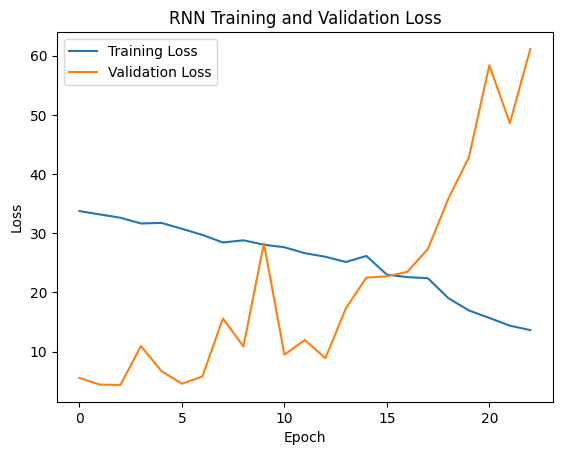

In [37]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN Training and Validation Loss')
plt.legend()
plt.show()

In [38]:
rnn_train_predictions = rnn_model.predict(X_train_rnn).flatten()
rnn_test_predictions = rnn_model.predict(X_test_rnn).flatten()

rnn_train_residuals = y_train - rnn_train_predictions
rnn_test_residuals = y_test - rnn_test_predictions

eval_metrics(y_train, rnn_train_predictions, "RNN Training Results")
print()
eval_metrics(y_test, rnn_test_predictions, "RNN Testing Results")

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
RNN Training Results
RMSE: 2.107
MAE: 1.673
R-squared: 0.988

RNN Testing Results
RMSE: 2.122
MAE: 1.696
R-squared: 0.988


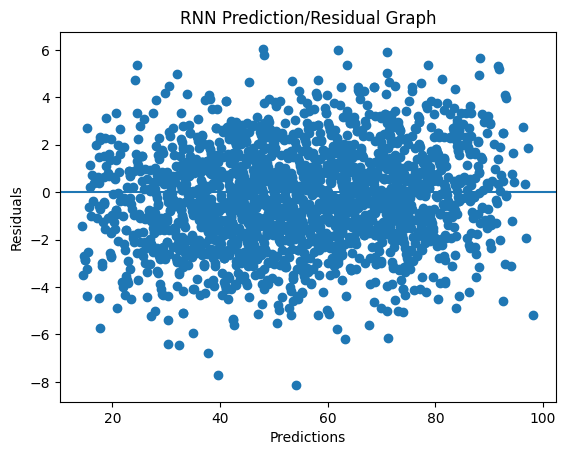

In [39]:
plt.scatter(rnn_test_predictions, rnn_test_residuals)
plt.axhline(y=0)
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.title('RNN Prediction/Residual Graph')
plt.show()

## Comparing all 3 models:

In [40]:
mlr_rmse = np.sqrt(result.mse_resid)
mlr_r2 = result.rsquared
mlr_adj_r2 = result.rsquared_adj

comparison = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression',
        'Random Forest Regression',
        'RNN Regression'
    ],
    'RMSE': [
        mlr_rmse,
        np.sqrt(mean_squared_error(y_test, rf_test_predictions)),
        np.sqrt(mean_squared_error(y_test, rnn_test_predictions))
    ],
    'MAE': [
        np.nan,
        mean_absolute_error(y_test, rf_test_predictions),
        mean_absolute_error(y_test, rnn_test_predictions)
    ],
    'R-squared': [
        mlr_r2,
        r2_score(y_test, rf_test_predictions),
        r2_score(y_test, rnn_test_predictions)
    ]
})

comparison

,Model,RMSE,MAE,R-squared
0,Multiple Linear Regression,2.038098,NaN,0.988752
1,Random Forest Regression,2.265960,1.810511,0.986145
2,RNN Regression,2.122186,1.695739,0.987847
